[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/syaikhipin/kdd26-memdiag/blob/tutorial-rebuild/tutorial/phase2_public_datasets/01_diagnostic_framework.ipynb)

> **Run this notebook in Google Colab** — click the badge above. The setup cell auto-clones the repo.


# Phase 2A - Diagnostic framework (Exercise 1)

**Phase 2A - Diagnostic framework & Exercise 1 (diagnose).** Independent notebook - runs standalone in Colab or locally (offline, no key).

## The 3-probe framework
- **Probe 1 retrieval:** precision/recall/F1 of retrieved evidence vs gold.
- **Probe 2 utilization:** 3-arm contrastive reader (no-context / oracle / provider) - `util != hit`.
- **Probe 3 failure root-cause:** retrieval_miss / partial / retrieved-but-unused.

## 0. Setup (self-contained)

In [ ]:
# Self-contained setup - works standalone in Google Colab or locally.
import sys, os, subprocess
from pathlib import Path
REPO_URL = "https://github.com/syaikhipin/kdd26-memdiag"
try:
    import google.colab  # noqa
    IN_COLAB = True
except Exception:
    IN_COLAB = False
if IN_COLAB:
    repo = Path("/content/kdd26-memdiag")
    if not repo.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", "tutorial-rebuild", REPO_URL, str(repo)], check=False)
    SOURCE = repo / "source"
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "matplotlib", "pyyaml", "openai"], check=False)
else:
    SOURCE = None
    for cand in [Path.cwd(), *Path.cwd().parents]:
        for sub in ("source", "experiment"):
            if (cand / sub / "run.py").exists():
                SOURCE = cand / sub
                break
        if SOURCE:
            break
    if SOURCE is None:
        raise FileNotFoundError("Run from the repo root (or in Colab it auto-clones).")
sys.path.insert(0, str(SOURCE))
SOURCE_DIR = SOURCE
PROJECT_ROOT = SOURCE.parent
RESULTS_DIR = PROJECT_ROOT / "results"
try: _d = "<repo>/" + str(Path(SOURCE).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d, "| found =", True, "| IN_COLAB =", IN_COLAB)

try: _d = "<repo>/" + str(Path(SOURCE_DIR).relative_to(PROJECT_ROOT))
except Exception: _d = "<repo>/source"
print("SOURCE_DIR =", _d)

## ⚙️ Set up your LLM at the beginning — base URL · API key · model
On first run this cell **prompts you for three things**: your OpenAI-compatible **base URL**, **API key** (hidden input), and **model**. They are saved to **Google Drive** in Colab (or a local file) so every other notebook and every future session reuses them — you set up **once**. Press **Enter** to keep a default / run offline. To reconfigure later: set `KDD_RECONFIG=1` or delete the saved config file shown below.

In [ ]:
# === Set up your LLM at the beginning: base URL · API key · model ===
# Prompts ONCE (saved to Google Drive in Colab / local file) -> reused by EVERY notebook & session.
# To re-prompt later: set os.environ['KDD_RECONFIG']='1', or delete the saved config file.
from config import setup_llm                       # shared helper in source/config.py
OPENAI_BASE_URL, OPENAI_API_KEY, OPENAI_MODEL = setup_llm()
from llm_client import LLMConfig, make_client
try:
    llm = make_client(LLMConfig(backend="openai-compatible" if OPENAI_API_KEY else "offline",
                                base_url=OPENAI_BASE_URL, model=OPENAI_MODEL))
    print("llm      =", llm.backend)
except Exception:
    llm = None
    print("llm      = (env vars set for CLI tools)")


## 📖 Narrative: Why diagnose before benchmarking?

Before we compare providers, we need to know **where** memory fails. The 3-probe framework
separates three failure modes that are often conflated:

- **Retrieval failure** — the right evidence was never retrieved (precision/recall)
- **Utilization failure** — the evidence was retrieved but the agent didn't use it
- **Storage failure** — the memory representation lost critical information

This distinction matters because the fix is different for each: retrieval needs better search,
utilization needs better prompting/grounding, storage needs better representation.

## Exercise 1 - memory failure diagnosis

In [3]:
import subprocess, re
from pathlib import Path
cmd = [sys.executable,'-m','diagnostic_framework','diagnose',
 '--strategies','verbatim,extracted_facts,episodic,hybrid',
 '--probes','relevance,utilization,failure','--top_k','5','--max-questions','20']
r = subprocess.run(cmd, cwd=str(SOURCE_DIR), capture_output=True, text=True)
def _mask(s):
    s = str(s)
    try: s = s.replace(str(PROJECT_ROOT), "<repo>")
    except NameError: pass
    return s.replace(str(Path.home()), "~")
print(_mask(r.stdout[-2200:]))
if r.returncode: print('STDERR:', _mask(r.stderr[-800:]))

strategy	questions	retr_p	retr_r	hit	util	lat_ms	cost	mem	sem_cov	sem	sem_pass	faith	ctx	ans
verbatim	20	0.060	0.275	0.300	0.200	0.76	12.4	419	1.000	0.265	0.000	0.050	0.695	0.050
extracted_facts	20	0.060	0.275	0.300	0.300	7.74	29.6	1282	1.000	0.274	0.050	0.096	0.628	0.096
episodic	20	0.002	0.142	0.200	0.100	0.11	4.4	19	1.000	0.118	0.000	0.017	0.321	0.017
hybrid	20	0.005	0.250	0.250	0.150	5.68	12.8	438	1.000	0.241	0.000	0.042	0.641	0.042

Raw trace: <repo>/results/run_20260810_125627_locomo_raw.json
Metrics: <repo>/results/run_20260810_125627_locomo_metrics.json
Summary TSV: <repo>/results/run_20260810_125627_locomo_summary.tsv



## 📖 Narrative: Reading the diagnostic table

Look at the `util` column vs `hit` column. If `util < hit`, the system retrieved the right
evidence but the agent couldn't use it — a **utilization failure**. If `util > hit`, the
context mentioned the answer even though the exact gold turn wasn't retrieved — meaning
**other turns carried the information**. The gap between `util` and `hit` is the
**utilization diagnostic signal**.

### 📝 Quick Quiz
1. **Which strategy has the highest retrieval hit on LoCoMo?** (Check the `hit` column)
2. **Is `util` ever different from `hit`?** Which strategy shows the biggest gap?
3. **What does `util=0.300, hit=0.300` mean?** Did the agent use the memory or not?

**Read it:** is `util` ever different from `hit`? That gap is the retrieval-vs-utilization failure.

### 📊 Visualize — 3-probe diagnostic (live result file)

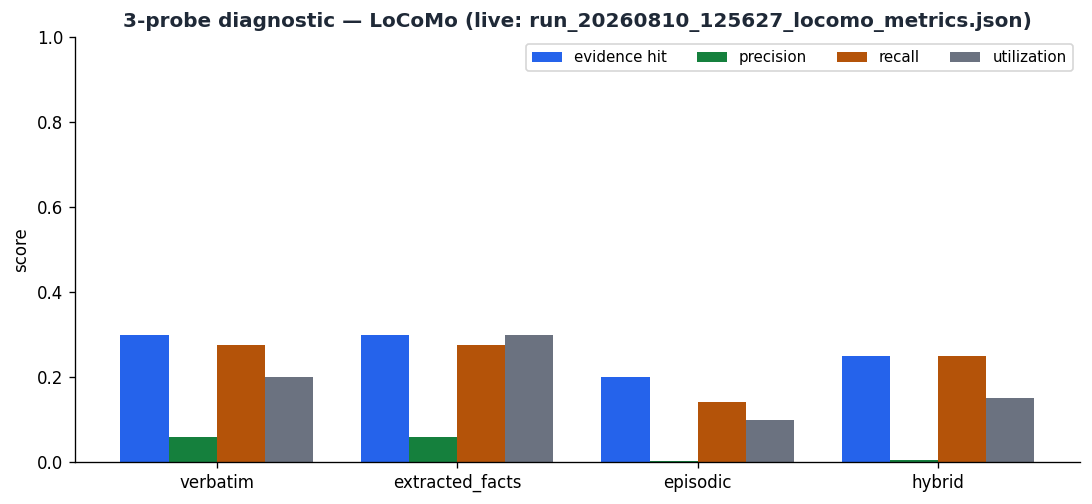

In [4]:
# Reads the latest run_*_locomo_metrics.json produced by the cell above; placeholder if absent.
import glob, json
from pathlib import Path
import matplotlib.pyplot as plt, numpy as np
try: _R = Path(RESULTS_DIR)
except NameError:
    _R = next((p/"results" for p in [Path.cwd(), *Path.cwd().parents] if (p/"results").is_dir()), Path.cwd()/"results")
_f = sorted(_R.glob("run_*_locomo_metrics.json"))
if not _f:
    print("No locomo_metrics.json yet — run the `diagnostic-framework diagnose` cell above first.")
else:
    by = json.load(open(_f[-1]))["locomo"]["by_strategy"]
    prov = list(by)
    hit = [by[p]["evidence_hit_rate"] for p in prov]
    P   = [by[p]["retrieval_precision"] for p in prov]
    R   = [by[p]["retrieval_recall"] for p in prov]
    U   = [by[p].get("utilization_rate",0.0) for p in prov]
    x=np.arange(len(prov)); w=0.2
    fig,ax=plt.subplots(figsize=(9.2,4.3),dpi=120)
    ax.bar(x-1.5*w,hit,w,label="evidence hit",color="#2563EB")
    ax.bar(x-0.5*w,P,w,label="precision",color="#15803D")
    ax.bar(x+0.5*w,R,w,label="recall",color="#B45309")
    ax.bar(x+1.5*w,U,w,label="utilization",color="#6B7280")
    ax.set_xticks(x); ax.set_xticklabels(prov); ax.set_ylabel("score"); ax.set_ylim(0,1.0)
    ax.set_title(f"3-probe diagnostic — LoCoMo (live: {_f[-1].name})",color="#1F2937",weight="bold")
    ax.legend(ncol=4,fontsize=9); ax.spines[["top","right"]].set_visible(False)
    fig.tight_layout(); plt.show()